In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset.csv")
df.columns=[str(c).strip().lower().replace(" ","_") for c in df.columns]
display(df.head())
print("Shape:",df.shape)
display(df.dtypes)

,booking_id,hotel_type,hotel_location,booking_date,arrival_date,lead_time_days,weekend_nights,weekday_nights,adults,children,...,meal_type,total_nights,adr,required_car_parking_spaces,total_special_requests,satisfaction_score,reservation_status,is_canceled,reservation_status_date,estimated_revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


Shape: (25180, 35)


booking_id                         str
hotel_type                         str
hotel_location                     str
booking_date                       str
arrival_date                       str
lead_time_days                   int64
weekend_nights                   int64
weekday_nights                   int64
adults                           int64
children                       float64
babies                           int64
country                            str
market_segment                     str
distribution_channel               str
is_repeated_guest                int64
previous_cancellations           int64
previous_bookings                int64
room_type_reserved                 str
room_type_assigned                 str
booking_changes                  int64
deposit_type                       str
agent_id                       float64
company_id                     float64
days_in_waiting_list             int64
customer_type                      str
meal_type                

In [3]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False))
print("Duplicate rows:",df.duplicated().sum())

for c in ["hotel_type","hotel_location","market_segment","distribution_channel","deposit_type","customer_type","meal_type","reservation_status"]:
    print("\n",c)
    display(df[c].value_counts().head(10))

Missing values:


company_id                     20729
country                          466
agent_id                         304
meal_type                        245
satisfaction_score               164
children                         121
hotel_location                   106
adr                               82
booking_id                         0
hotel_type                         0
lead_time_days                     0
babies                             0
market_segment                     0
distribution_channel               0
booking_date                       0
weekend_nights                     0
weekday_nights                     0
adults                             0
arrival_date                       0
room_type_assigned                 0
room_type_reserved                 0
previous_bookings                  0
previous_cancellations             0
is_repeated_guest                  0
days_in_waiting_list               0
booking_changes                    0
deposit_type                       0
t

Duplicate rows: 180

 hotel_type


hotel_type
City Hotel      15606
Resort Hotel     9454
CITY HOTEL         44
city hotel         43
City hotel         33
Name: count, dtype: int64


 hotel_location


...

customer_type
Contract           6446
Transient-Party    6329
Group              6328
Transient          6077
Name: count, dtype: int64


 meal_type


meal_type
BB           5027
Undefined    4978
SC           4945
HB           4939
FB           4939
BB             38
bb             32
 B&B           30
Unknown         7
Name: count, dtype: int64


 reservation_status


reservation_status
Canceled     16723
Check-Out     7006
No-Show       1451
Name: count, dtype: int64

Cleaning and Feature Engineering

In [4]:
mp={"hotel_type":"hotel","lead_time_days":"lead_time","weekend_nights":"stays_in_weekend_nights","weekday_nights":"stays_in_week_nights","room_type_reserved":"reserved_room_type","room_type_assigned":"assigned_room_type","meal_type":"meal","agent_id":"agent","company_id":"company"}
d=df.rename(columns=mp).copy()
d["children"]=pd.to_numeric(d["children"],errors="coerce").fillna(d["children"].median())
for c in ["country","agent","company"]: d[c]=d[c].fillna("Unknown")
before=len(d); d=d.drop_duplicates().copy()
d["booking_date"]=pd.to_datetime(d["booking_date"],errors="coerce")
d["arrival_date"]=pd.to_datetime(d["arrival_date"],errors="coerce")
d["arrival_year"]=d["arrival_date"].dt.year
d["arrival_month_num"]=d["arrival_date"].dt.month
d["arrival_month"]=d["arrival_date"].dt.month_name()
d["total_nights"]=d["stays_in_weekend_nights"]+d["stays_in_week_nights"]
d["total_guests"]=d["adults"]+d["children"]+d["babies"]
print("Duplicate rows removed:",before-len(d))
print("Missing values after cleaning:",int(d.isna().sum().sum()))

Duplicate rows removed: 180
Missing values after cleaning: 584


Descriptive Statistics and Univariate Analysis

,count,mean,min,25%,50%,75%,max,std
booking_date,25000,2025-01-01 02:16:03.072000,2024-01-01 00:00:00,2024-07-01 00:00:00,2024-12-30 12:00:00,2025-07-05 00:00:00,2025-12-31 00:00:00,NaN
arrival_date,25000,2025-07-02 05:55:37.344000,2024-01-02 00:00:00,2024-12-30 00:00:00,2025-07-02 00:00:00,2026-01-03 00:00:00,2026-12-29 00:00:00,NaN
lead_time,25000.0,182.2174,0.0,91.0,182.0,273.0,920.0,105.632493
stays_in_weekend_nights,25000.0,1.24088,0.0,0.0,1.0,2.0,3.0,1.064003
stays_in_week_nights,25000.0,2.45,0.0,1.0,2.0,4.0,13.0,2.03007
adults,25000.0,2.19848,1.0,2.0,2.0,2.0,7.0,0.662226
children,25000.0,0.37068,0.0,0.0,0.0,1.0,6.0,0.65679
babies,25000.0,0.04312,0.0,0.0,0.0,0.0,2.0,0.22535
is_repeated_guest,25000.0,0.17288,0.0,0.0,0.0,0.0,1.0,0.378151
previous_cancellations,25000.0,0.03856,0.0,0.0,0.0,0.0,3.0,0.250989


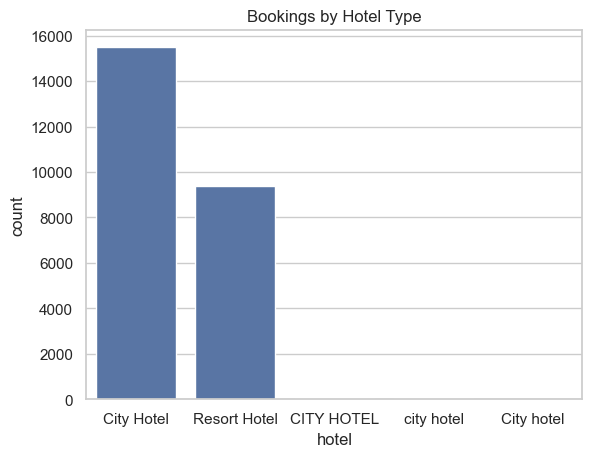

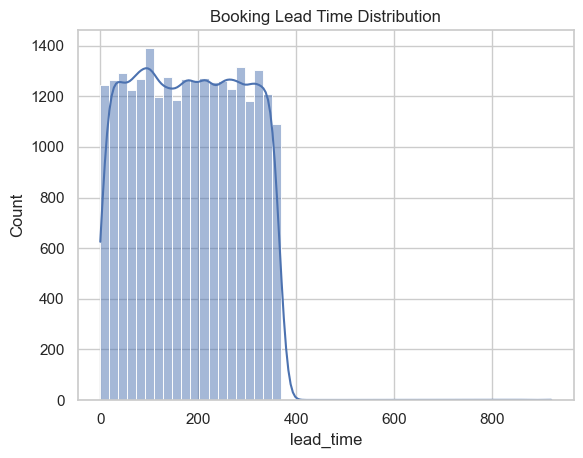

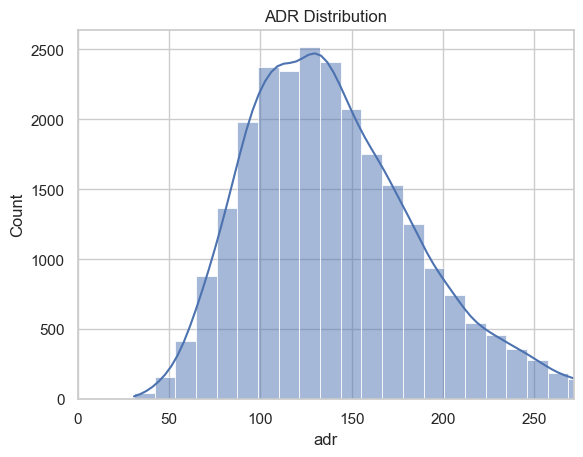

In [5]:
display(d.describe().T)
sns.set_theme(style="whitegrid")

sns.countplot(x="hotel",data=d)
plt.title("Bookings by Hotel Type")
plt.show()

sns.histplot(data=d,x="lead_time",bins=50,kde=True)
plt.title("Booking Lead Time Distribution")
plt.show()

sns.histplot(data=d,x="adr",bins=60,kde=True)
plt.xlim(0,d["adr"].quantile(.99))
plt.title("ADR Distribution")
plt.show()

Outlier Detection — IQR

,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outliers,Outlier_%
3,adults,2.000,2.0000,2.00000,2.00000,7529,30.116
7,previous_bookings,0.000,0.0000,0.00000,0.00000,4322,17.288
9,days_in_waiting_list,0.000,1.0000,-1.50000,2.50000,4082,16.328
8,booking_changes,0.000,1.0000,-1.50000,2.50000,1279,5.116
5,babies,0.000,0.0000,0.00000,0.00000,959,3.836
6,previous_cancellations,0.000,0.0000,0.00000,0.00000,687,2.748
14,estimated_revenue,230.620,737.5700,-529.80500,1497.99500,652,2.608
10,adr,105.605,169.0825,10.38875,264.29875,356,1.424
13,satisfaction_score,3.590,4.1300,2.78000,4.94000,246,0.984
4,children,0.000,1.0000,-1.50000,2.50000,210,0.840


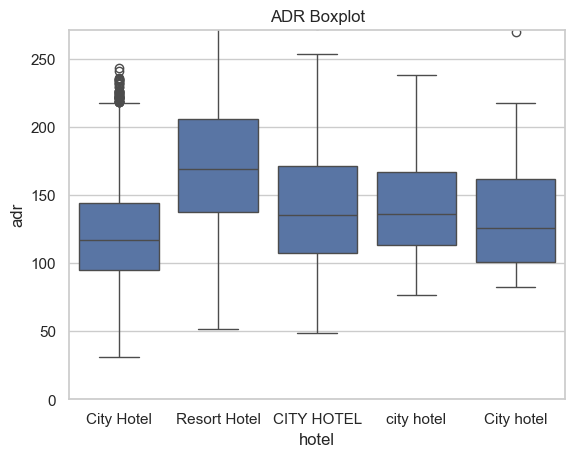

In [6]:
out_cols=["lead_time","stays_in_weekend_nights","stays_in_week_nights","adults","children","babies","previous_cancellations","previous_bookings","booking_changes","days_in_waiting_list","adr","total_nights","total_special_requests","satisfaction_score","estimated_revenue"]
rows=[]
for c in out_cols:
    q1,q3=d[c].quantile([.25,.75]); iq=q3-q1
    lo,hi=q1-1.5*iq,q3+1.5*iq
    n=((d[c]<lo)|(d[c]>hi)).sum()
    rows.append([c,q1,q3,lo,hi,int(n),100*n/len(d)])
outlier_df=pd.DataFrame(rows,columns=["Feature","Q1","Q3","Lower_Bound","Upper_Bound","Outliers","Outlier_%"])
display(outlier_df.sort_values("Outlier_%",ascending=False))

sns.boxplot(x="hotel",y="adr",data=d)
plt.ylim(0,d["adr"].quantile(.99))
plt.title("ADR Boxplot")
plt.show()

Bivariate and Group-wise Analysis

In [7]:
hotel_stats=d.groupby("hotel").agg(
    bookings=("hotel","size"),
    cancellation_rate=("is_canceled","mean"),
    avg_adr=("adr","mean"),
    avg_lead_time=("lead_time","mean"),
    avg_nights=("total_nights","mean"),
    avg_satisfaction=("satisfaction_score","mean"))
market_stats=d.groupby("market_segment").agg(
    bookings=("hotel","size"),
    cancellation_rate=("is_canceled","mean"),
    avg_adr=("adr","mean"),
    avg_revenue=("estimated_revenue","mean")).sort_values("bookings",ascending=False)
deposit_stats=d.groupby("deposit_type").agg(
    bookings=("hotel","size"),
    cancellation_rate=("is_canceled","mean"),
    avg_adr=("adr","mean")).sort_values("cancellation_rate",ascending=False)

display(hotel_stats)
display(market_stats)
display(deposit_stats)

,bookings,cancellation_rate,avg_adr,avg_lead_time,avg_nights,avg_satisfaction
hotel,,,,,,
CITY HOTEL,44,0.750000,145.121591,169.500000,3.613636,3.852273
City Hotel,15491,0.733329,120.542586,182.962172,3.192112,3.851880
City hotel,33,0.575758,137.682727,145.393939,3.939394,3.833939
Resort Hotel,9389,0.703057,173.699257,181.032804,4.513793,3.858507
city hotel,43,0.720930,146.173256,213.837209,3.581395,3.867907


,bookings,cancellation_rate,avg_adr,avg_revenue
market_segment,,,,
Online TA,10702,0.751916,143.357848,547.580627
Offline TA/TO,5440,0.704228,142.421577,541.230465
Direct,3808,0.712185,143.281800,550.958506
Corporate,2990,0.674916,134.155128,499.201207
Groups,1910,0.697906,125.283621,480.228204
ONLINE TA,52,0.615385,135.690000,497.624615
online ta,50,0.740000,139.066939,479.179800
Online TA,48,0.708333,127.681458,457.602292


,bookings,cancellation_rate,avg_adr
deposit_type,,,
Non Refund,12401,0.929764,139.646264
Refundable,455,0.547253,141.349780
No Deposit,12144,0.515893,141.561777


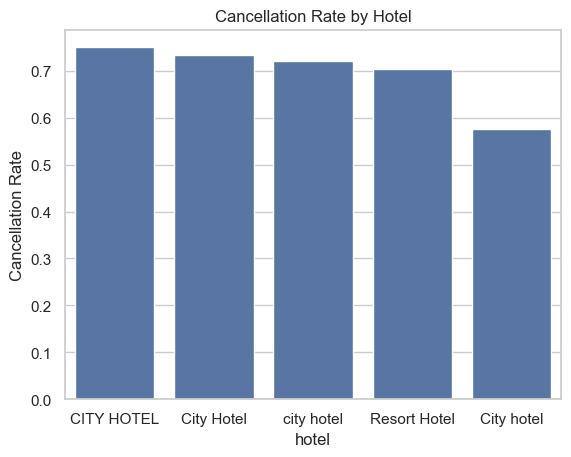

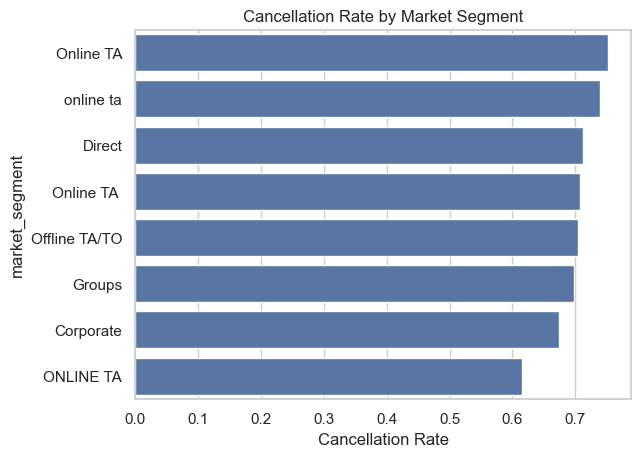

In [8]:
hotel_cancel=d.groupby("hotel")["is_canceled"].mean().sort_values(ascending=False)
sns.barplot(x=hotel_cancel.index,y=hotel_cancel.values)
plt.ylabel("Cancellation Rate")
plt.title("Cancellation Rate by Hotel")
plt.show()

market_cancel=d.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False)
sns.barplot(y=market_cancel.index,x=market_cancel.values)
plt.xlabel("Cancellation Rate")
plt.title("Cancellation Rate by Market Segment")
plt.show()

Time Analysis

,arrival_year,arrival_month_num,bookings,cancellations,avg_adr
0,2024,1,38,19,125.276316
1,2024,2,145,67,121.961655
2,2024,3,193,84,113.457083
3,2024,4,304,157,142.302392
4,2024,5,408,220,140.199754
5,2024,6,460,263,158.822723
6,2024,7,610,380,161.496338
7,2024,8,648,398,159.792372
8,2024,9,728,485,139.466547
9,2024,10,822,568,140.925086


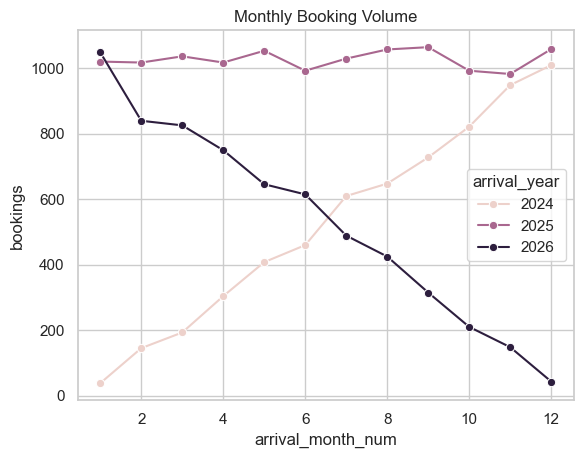

In [9]:
monthly=d.groupby(["arrival_year","arrival_month_num"]).agg(
    bookings=("hotel","size"),
    cancellations=("is_canceled","sum"),
    avg_adr=("adr","mean")).reset_index()
display(monthly)

sns.lineplot(data=monthly,x="arrival_month_num",y="bookings",hue="arrival_year",marker="o")
plt.title("Monthly Booking Volume")
plt.show()

Correlation Analysis

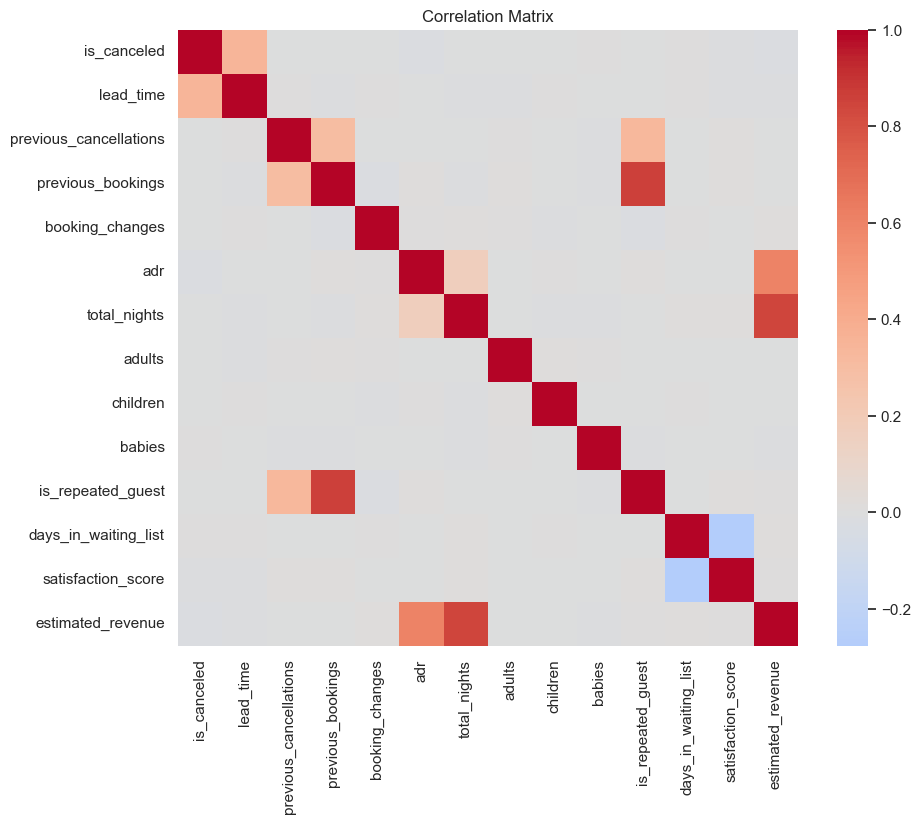

is_canceled               1.000000
lead_time                 0.343847
babies                    0.004334
days_in_waiting_list      0.003421
previous_cancellations    0.001858
is_repeated_guest        -0.001286
children                 -0.001298
previous_bookings        -0.001374
booking_changes          -0.002029
total_nights             -0.003850
adults                   -0.005442
satisfaction_score       -0.010468
estimated_revenue        -0.013002
adr                      -0.016988
Name: is_canceled, dtype: float64

In [10]:
corr_cols=["is_canceled","lead_time","previous_cancellations","previous_bookings","booking_changes","adr","total_nights","adults","children","babies","is_repeated_guest","days_in_waiting_list","satisfaction_score","estimated_revenue"]
corr=d[corr_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,cmap="coolwarm",center=0,annot=False)
plt.title("Correlation Matrix")
plt.show()
display(corr["is_canceled"].sort_values(ascending=False))